<a href="https://colab.research.google.com/github/DiegoJimenez2003/MineriaDeDatos/blob/main/NotebookMineria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Evaluación 1 - Preparacion de los datos**

**Integrantes:**

+ Diego Jimenez
+ Sebastian Quilodran
+ Brayan Cid

**Fecha de Entrega:** 26 de marzo de 2026

---

## Descripción

Este notebook contiene las interpretaciones de los insight y reconocimiento de los datos. que se Encuentran en la base de datos del clima de chile.

## Herramientas y lenguaje utilizado

Este notebook fue desarrollado con Python y con las siguientes librerias:


*   pandas
*   numpy
*   matplotlib
*   seaborn
*   plotly.express

## Insight Asignados
  + Por localidad y mes, ¿entre qué rango horario se dan las temperaturas mínimas y máximas?
  + Por mes, ¿cuál es la diferencia sistemática entre temperatura real y aparente?

## **Importacion y carga de los datos**

### **cargas de libreria**


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

### **carga de la data**


In [17]:
!wget https://raw.githubusercontent.com/DiegoJimenez2003/MineriaDeDatos/master/data_clima_2025_final.csv

--2026-03-26 01:25:54--  https://raw.githubusercontent.com/DiegoJimenez2003/MineriaDeDatos/master/data_clima_2025_final.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4527300 (4.3M) [text/plain]
Saving to: ‘data_clima_2025_final.csv.1’

data_clima_2025_fin 100%[===================>]   4.32M  --.-KB/s    in 0.01s   

2026-03-26 01:25:54 (312 MB/s) - ‘data_clima_2025_final.csv.1’ saved [4527300/4527300]



## **Reconociendo la data**


Damos un vistaso a la Data utilizando Data_frame que nos permite ver todos los datos presentes en nuestro archivo .csv

In [4]:
data_frame = pd.read_csv("data_clima_2025_final.csv")
data_frame

,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,sunshine_duration,Localidad,latitud,longitud,is_rainy_hour
0,2025-01-01 03:00:00+00:00,15.100,72.053330,13.451475,0.0,0.0,11.609651,187.12492,0.0,0.0,0.0,"Concepción, Chile",-36.827070,-73.050206,0
1,2025-01-01 04:00:00+00:00,14.900,64.437440,12.787600,0.0,0.0,11.341428,179.09064,0.0,0.0,0.0,"Concepción, Chile",-36.827070,-73.050206,0
2,2025-01-01 05:00:00+00:00,14.400,63.023464,12.131762,0.0,0.0,11.032987,174.38250,0.0,0.0,0.0,"Concepción, Chile",-36.827070,-73.050206,0
3,2025-01-01 06:00:00+00:00,13.900,65.991730,11.714258,0.0,0.0,10.805999,178.09090,0.0,0.0,0.0,"Concepción, Chile",-36.827070,-73.050206,0
4,2025-01-01 07:00:00+00:00,13.400,70.770430,11.426943,0.0,0.0,10.299397,185.01303,0.0,0.0,0.0,"Concepción, Chile",-36.827070,-73.050206,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33019,2025-12-10 22:00:00+00:00,10.512,80.853900,6.354998,0.3,100.0,23.838959,321.74550,0.3,1.0,0.0,"Punta Arenas, Chile",-53.162569,-70.907822,1
33020,2025-12-10 23:00:00+00:00,10.562,84.234474,6.163400,0.2,100.0,26.604097,315.82227,0.2,1.0,0.0,"Punta Arenas, Chile",-53.162569,-70.907822,1
33021,2025-12-11 00:00:00+00:00,10.912,83.989340,5.895717,0.1,100.0,31.366001,305.42310,0.1,1.0,0.0,"Punta Arenas, Chile",-53.162569,-70.907822,1
33022,2025-12-11 01:00:00+00:00,10.562,82.532370,5.911911,0.1,100.0,27.811600,304.71866,0.1,1.0,0.0,"Punta Arenas, Chile",-53.162569,-70.907822,1


Como ya tenemos el archivo csv cargaremos los datos.
Es necesario cargar los datos ya que esto nos permite "selecionar" la data para que se pueda leer atraves de los codigos que se utilizaran

In [18]:
data = pd.read_csv("data_clima_2025_final.csv")
data.shape

(33024, 15)

Se ocupa head para visualizar los 5 primeros registros para ver si se cargaron correctamente.

In [19]:
data.head()

,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,sunshine_duration,Localidad,latitud,longitud,is_rainy_hour
0,2025-01-01 03:00:00+00:00,15.1,72.053330,13.451475,0.0,0.0,11.609651,187.12492,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
1,2025-01-01 04:00:00+00:00,14.9,64.437440,12.787600,0.0,0.0,11.341428,179.09064,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
2,2025-01-01 05:00:00+00:00,14.4,63.023464,12.131762,0.0,0.0,11.032987,174.38250,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
3,2025-01-01 06:00:00+00:00,13.9,65.991730,11.714258,0.0,0.0,10.805999,178.09090,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
4,2025-01-01 07:00:00+00:00,13.4,70.770430,11.426943,0.0,0.0,10.299397,185.01303,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0


Utilizaremos Data.isnull para detectar los valores nulos presente en la Data,  donde podemos identificar que la data actualmente no presenta ningun nulo en ninguna columna

In [7]:
data.isnull().sum()

,0
date,0
temperature_2m,0
relative_humidity_2m,0
apparent_temperature,0
precipitation,0
cloud_cover,0
wind_speed_10m,0
wind_direction_10m,0
rain,0
is_day,0


Aqui se puede identidicar la presencia de valores negativos o 0 en la data, esto nos ayudara a tomar mejor decisiones en el futuro.

In [20]:
for column in data.columns:
    if data[column].dtype in ['int64', 'float64']:
        negative_count = (data[column] < 0).sum()
        zero_count = (data[column] == 0).sum()
        if negative_count > 0 or zero_count > 0:
            print(f"La columna '{column}' tiene {negative_count} valores negativos y {zero_count} ceros.")
    else:
        print(f"La columna '{column}' no es numérica, no se verifican negativos ni ceros.")

La columna 'date' no es numérica, no se verifican negativos ni ceros.
La columna 'temperature_2m' tiene 271 valores negativos y 4 ceros.
La columna 'apparent_temperature' tiene 3400 valores negativos y 0 ceros.
La columna 'precipitation' tiene 0 valores negativos y 26872 ceros.
La columna 'cloud_cover' tiene 0 valores negativos y 4717 ceros.
La columna 'wind_speed_10m' tiene 0 valores negativos y 15 ceros.
La columna 'rain' tiene 0 valores negativos y 26924 ceros.
La columna 'is_day' tiene 0 valores negativos y 16648 ceros.
La columna 'sunshine_duration' tiene 0 valores negativos y 20257 ceros.
La columna 'Localidad' no es numérica, no se verifican negativos ni ceros.
La columna 'latitud' tiene 33024 valores negativos y 0 ceros.
La columna 'longitud' tiene 33024 valores negativos y 0 ceros.
La columna 'is_rainy_hour' tiene 0 valores negativos y 26924 ceros.


Utilizaremos data.describe para obtener una informacion mas detallada sobre la data en cada uno de sus columnas

In [8]:
data.describe()

,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,sunshine_duration,latitud,longitud,is_rainy_hour
count,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000
mean,10.644075,79.042842,8.337603,0.138981,62.114977,11.930189,205.227225,0.136601,0.495882,1221.216663,-42.134914,-72.448638,0.184714
std,5.213359,16.228987,6.350746,0.582210,41.871036,8.474665,101.410042,0.577866,0.499991,1650.360797,6.456137,0.920869,0.388071
min,-5.100000,15.230701,-8.741941,0.000000,0.000000,0.000000,0.367278,0.000000,0.000000,0.000000,-53.162569,-73.245986,0.000000
25%,7.050000,68.349886,3.876656,0.000000,13.000000,5.649248,139.531913,0.000000,0.000000,0.000000,-43.151237,-73.099151,0.000000
50%,10.400000,82.217838,8.232820,0.000000,88.000000,9.940824,229.398790,0.000000,0.000000,0.000000,-39.275008,-72.820372,0.000000
75%,13.700000,92.891105,12.350445,0.000000,100.000000,15.882896,284.036250,0.000000,1.000000,3600.000000,-38.258686,-72.169859,0.000000
max,31.750000,100.000000,32.108310,13.200000,100.000000,65.250920,360.000000,13.200000,1.000000,3600.000000,-36.827070,-70.907822,1.000000


####**Obtencion de Valores atipicos de manera general en la data**

In [22]:
outlier_summary = []

for column in data.select_dtypes(include=np.number).columns:
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)][column]

    if not outliers.empty:
        min_outlier = outliers.min()
        max_outlier = outliers.max()
    else:
        min_outlier = 'N/A'
        max_outlier = 'N/A'

    outlier_summary.append({
        'Variable': column,
        'Número de Atípicos': len(outliers),
        'Límite Inferior (IQR 1)': lower_bound,
        'Límite Superior (IQR 3)': upper_bound,
        'Valor Atípico Mínimo': min_outlier,
        'Valor Atípico Máximo': max_outlier
    })

outlier_df = pd.DataFrame(outlier_summary)

print("Resumen de Valores Atípicos por Columna:")
print(outlier_df.to_string(index=False))

Resumen de Valores Atípicos por Columna:
            Variable  Número de Atípicos  Límite Inferior (IQR 1)  Límite Superior (IQR 3) Valor Atípico Mínimo Valor Atípico Máximo
      temperature_2m                 476                -2.925000                23.675000                 -5.1                31.75
relative_humidity_2m                 130                31.538059               129.702933            15.230701             31.46339
apparent_temperature                 282                -8.834028                25.061129            25.089315             32.10831
       precipitation                6152                 0.000000                 0.000000                  0.1                 13.2
         cloud_cover                   0              -117.500000               230.500000                  N/A                  N/A
      wind_speed_10m                1241                -9.701225                31.233369            31.259945             65.25092
  wind_direction_10m        

## Variables selecionadas
Una vez conocida la data debemos de identificar y conocer las variables presentes en la data que son:
+ Variable Cuantitativa
+ Variable Cualitativa

por lo cual Utilizaremos Info para detectar las variables Cualitativas y Cuantitativas

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33024 entries, 0 to 33023
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  33024 non-null  object 
 1   temperature_2m        33024 non-null  float64
 2   relative_humidity_2m  33024 non-null  float64
 3   apparent_temperature  33024 non-null  float64
 4   precipitation         33024 non-null  float64
 5   cloud_cover           33024 non-null  float64
 6   wind_speed_10m        33024 non-null  float64
 7   wind_direction_10m    33024 non-null  float64
 8   rain                  33024 non-null  float64
 9   is_day                33024 non-null  float64
 10  sunshine_duration     33024 non-null  float64
 11  Localidad             33024 non-null  object 
 12  latitud               33024 non-null  float64
 13  longitud              33024 non-null  float64
 14  is_rainy_hour         33024 non-null  int64  
dtypes: float64(12), int

### Variable Cuantitativa

Selecionamos la Variable Temperatura como nuestra variable Cuantitativa por lo cual le haremos un describe para obtener una data mas detallada.

In [11]:
data.temperature_2m.describe()

,temperature_2m
count,33024.000000
mean,10.644075
std,5.213359
min,-5.100000
25%,7.050000
50%,10.400000
75%,13.700000
max,31.750000


#### Identificando atipicos
Buscamos identificar los atipicos de la variable objetivo cuantitativa

In [15]:
# Obtenemos los valores de la variable temperature_2m
Q1 = data['temperature_2m'].quantile(0.25)
Q3 = data['temperature_2m'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['temperature_2m'] < lower_bound) | (data['temperature_2m'] > upper_bound)]

outlier_count_df = pd.DataFrame({
    'Variable': ['temperature_2m'],
    'Número de Atípicos': [len(outliers)],
    'Límite Inferior (IQR)': [lower_bound],
    'Límite Superior (IQR)': [upper_bound]
})

print("Valores Atípicos en temperature_2m:")
print(outlier_count_df.to_string(index=False))

Valores Atípicos en temperature_2m:
      Variable  Número de Atípicos  Límite Inferior (IQR)  Límite Superior (IQR)
temperature_2m                 476                 -2.925                 23.675


Representaremos la presencia de atipicos atravez de un grafico de boxplot para tener una referencia visual de estos.

Text(0.5, 1.0, 'Valores atípicos de la temperatura')

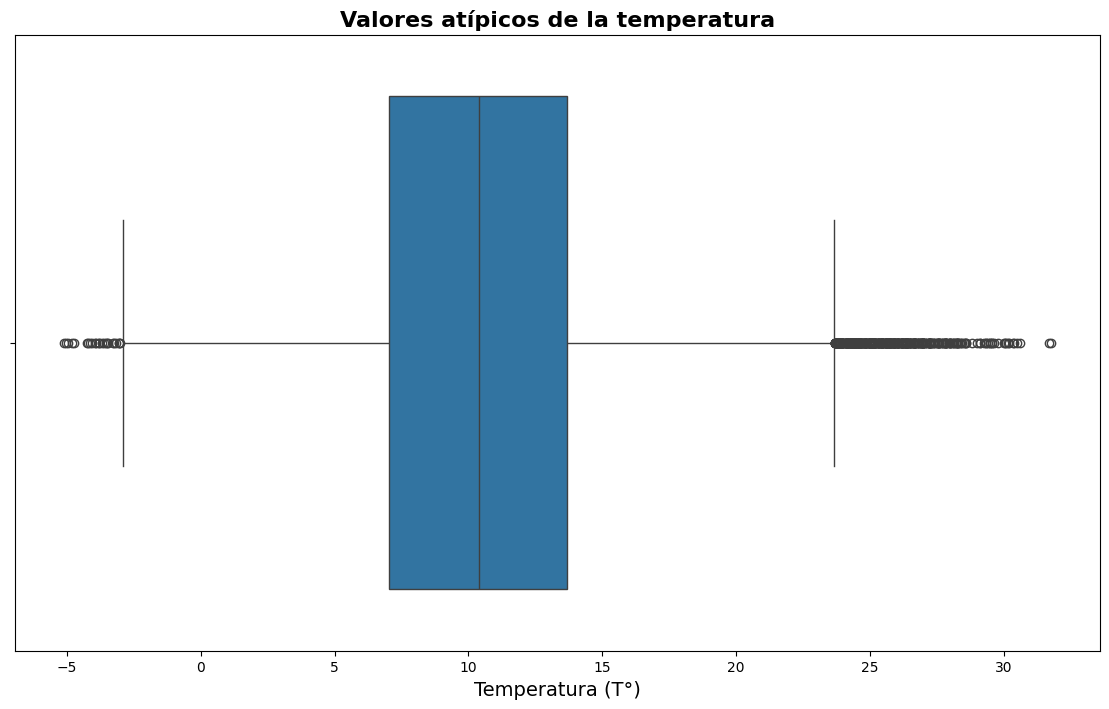

In [14]:
plt.figure(figsize=(14,8))
sns.boxplot(x=data.temperature_2m, data=data)
plt.xlabel('Temperatura (T°)', fontsize=14)
plt.title(r'Valores atípicos de la temperatura', fontsize=16, fontweight="bold")

### Variable Cualitativa

Selecionamos Localidad como variable cualitativa por lo cual aplicaremos un describe sobre esa data para obtener informacion detallada sobre las localidades

In [10]:
data.Localidad.describe()

,Localidad
count,33024
unique,4
top,"Concepción, Chile"
freq,8256


## **Interpretacion de los insight**

### Primer Insight
+ Por localidad y mes, ¿entre qué rango horario se dan las temperaturas mínimas y máximas?

In [ ]:
data['date'] = pd.to_datetime(data['date'])
data['Mes'] = data['date'].dt.month
data['Hora'] = data['date'].dt.hour

# Calculate min and max temperatures by Localidad, Mes, and Hora
temp_ranges = data.groupby(['Localidad', 'Mes', 'Hora'])['temperature_2m'].agg(['min', 'max']).reset_index()

# Plotting with plotly for better interactivity
fig = px.line(
    temp_ranges,
    x='Hora',
    y=['min', 'max'],
    color='Localidad',
    line_group='Localidad',
    animation_frame='Mes',
    labels={'min': 'Temperatura Mínima', 'max': 'Temperatura Máxima', 'Hora': 'Hora del Día', 'Mes': 'Mes'},
    title='Rango Horario de Temp Mín y Máx por Localidad y Mes',
    height=600
)

fig.update_layout(
    xaxis = dict(
        tickmode = 'array',
        tickvals = list(range(24)),
        ticktext = [f'{h:02d}:00' for h in range(24)]
    )
)

fig.show()

Se puede observar gracias al grafico que en las distintas localidades se logra alcanzar el maximo de temperatura entre las 18:00hrs a 19:00hrs aproximadamente y las temperaturas minimas entre las 8:00hrs a 9:00hrs.

Cabe aclarar que esto varia segun los meses y la estacion del año pero en general se estima y ronda en horarios similares

### Segundo insight
+ Por mes, ¿cuál es la diferencia sistemática entre temperatura real y aparente?

In [12]:
data['date'] = pd.to_datetime(data['date'])
data['Mes'] = data['date'].dt.month

# Calcula la diferencia sistematica entre la temperatura real y la aparente
data['temp_diff'] = data['temperature_2m'] - data['apparent_temperature']

# Calcula la diferencia media por mes.
monthly_diff = data.groupby('Mes')['temp_diff'].mean().reset_index()

# Representación gráfica de la diferencia sistemática por mes
fig = px.line(
    monthly_diff,
    x='Mes',
    y='temp_diff',
    title='Diferencia Sistemática (Temperatura Real - Aparente) por Mes',
    labels={'Mes': 'Mes del Año', 'temp_diff': 'Diferencia Promedio (°C)'},
    markers=True
)

fig.update_layout(
    xaxis = dict(
        tickmode = 'array',
        tickvals = list(range(1, 13)),
        ticktext = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
    )
)

fig.show()

Para interpretar la diferencia sistemática entre la temperatura real y aparente por mes, se ha calculado la diferencia promedio para cada mes y se visualizo con un gráfico de líneas. Este tipo de gráfico es ideal porque permite ver claramente las tendencias estacionales y las variaciones a lo largo del año, haciendo que la interpretación sea más intuitiva que una tabla.


Esta diferencia entre la temperatura real y la aparente (también conocida como sensación térmica) se ve influenciada principalmente por la humedad y el viento. Durante los meses más fríos y ventosos, el cuerpo humano percibe una temperatura más baja de lo que realmente es, lo que explica por qué la temperatura aparente es menor que la real, y esta diferencia se acentúa en invierno. En cambio, en verano, la diferencia es menor, aunque sigue existiendo.